### ***Notebook 02 — Statistical Analysis of Original Grayscale Images***

#### Objective

The objective of this notebook is to quantitatively analyze the statistical characteristics of the original grayscale inspection images.

The analyses performed in this notebook aim to identify image properties that directly influence preprocessing decisions, model design, and training strategies.

Only analyses that provide actionable engineering insights will be performed.

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro,levene,f_oneway,kruskal
import pandas as pd
import numpy as np
from PIL import Image

# =========================================================
# Project Setup
# =========================================================

from pathlib import Path
import sys

# Project Root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root :", PROJECT_ROOT)

Project Root : d:\Study\industrial_visual_inspection


## Research Question

> **RQ-006**

What statistical characteristics of the original grayscale images should guide preprocessing and model development?

#### Scope

This notebook analyzes only the original grayscale images (`.jpg`).

Segmentation masks will be investigated separately in Notebook 03.

The analyses performed here are intended to answer practical engineering questions rather than provide descriptive statistics alone.

| ID           | Investigation                | Why?                             |
| ------------ | ---------------------------- | -------------------------------- |
| **RQ-006.1** | Image dimensions             | Resize strategy                  |
| **RQ-006.2** | Pixel intensity distribution | Normalization                    |
| **RQ-006.3** | Brightness analysis          | Illumination correction          |
| **RQ-006.4** | Contrast analysis            | Histogram equalization?          |
| **RQ-006.5** | Image sharpness              | Blur detection                   |
| **RQ-006.6** | Noise analysis               | Denoising required?              |
| **RQ-006.7** | Inter-class comparison       | Do classes differ statistically? |


**Investigation 1- Image Dimensions**

Do the images have consistent spatial dimensions, and is resizing required before model training?

`Why start here?`

Because the answer immediately affects:

- Resize strategy
- Padding strategy
- Batch construction
- Memory consumption
- Model architecture

If all images had identical dimensions, preprocessing would be simpler. If dimensions vary substantially—as we already observed in the auditor—we'll need to justify a resizing policy before training.

In [7]:
DATASET_ROOT = Path("../data/raw/magnetic_tile")

records = []

for image_path in sorted(DATASET_ROOT.rglob("*.jpg")):

    with Image.open(image_path) as img:

        width, height = img.size

    records.append(
        {
            "path":image_path,
            "class": image_path.parent.parent.name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "resolution": f"{width}×{height}"
        }
    )

image_df = pd.DataFrame(records)

image_df.sample(5)

,path,class,width,height,aspect_ratio,resolution
647,..\data\raw\magnetic_tile\MT_Free\Imgs\exp3_nu...,MT_Free,514,375,1.370667,514×375
51,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...,MT_Blowhole,116,290,0.400000,116×290
445,..\data\raw\magnetic_tile\MT_Free\Imgs\exp1_nu...,MT_Free,604,243,2.485597,604×243
1303,..\data\raw\magnetic_tile\MT_Uneven\Imgs\exp4_...,MT_Uneven,512,335,1.528358,512×335
946,..\data\raw\magnetic_tile\MT_Free\Imgs\exp5_nu...,MT_Free,193,316,0.610759,193×316


In [8]:
print(f'Number of Unique Dimensions-> {image_df['resolution'].nunique()}')
print(f'Number of Total Images-> {image_df.shape[0]}')
print(f'Percentage of Unique Images-> {round(image_df['resolution'].nunique()/image_df.shape[0]*100,2)}%')


Number of Unique Dimensions-> 1225
Number of Total Images-> 1344
Percentage of Unique Images-> 91.15%


### Results

| Metric | Value |
|---------|------:|
| Total Images | **1344** |
| Unique Image Dimensions | **1225** |
| Percentage of Unique Dimensions | **91.15%** |

---

### Observations

- **What do we observe?**  
  The dataset contains images with highly variable spatial dimensions, with **1225 unique resolutions across 1344 images**.

- **Why does it matter?**  
  CNN architectures require fixed-size inputs, making a resizing strategy necessary before model training.

- **What decision does it lead to?**  
  All images must be resized to a common input size before training. However, before selecting a resizing strategy, we should investigate whether aspect ratios are consistent or if resizing may introduce geometric distortion.

## Research Question

> **RQ-006.1.1**

Should the original image aspect ratio be preserved during resizing?

---

### Motivation

Different aspect ratios may introduce geometric distortion during resizing, potentially affecting defect morphology and model performance.

---

### Method

Analyze the distribution of image aspect ratios across the dataset and quantify their variability.

ASPECT RATIO STATISTICS
Minimum : 0.356
Maximum : 2.678
Mean    : 1.052
Median  : 0.845
Std Dev : 0.554


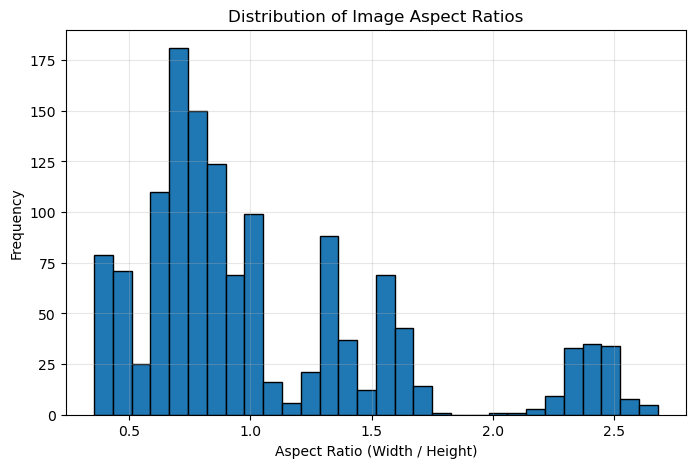

In [9]:
# ---------------------------------------------------------
# Aspect Ratio Statistics
# ---------------------------------------------------------

aspect_ratio = image_df["aspect_ratio"]

print("=" * 60)
print("ASPECT RATIO STATISTICS")
print("=" * 60)

print(f"Minimum : {aspect_ratio.min():.3f}")
print(f"Maximum : {aspect_ratio.max():.3f}")
print(f"Mean    : {aspect_ratio.mean():.3f}")
print(f"Median  : {aspect_ratio.median():.3f}")
print(f"Std Dev : {aspect_ratio.std():.3f}")

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    aspect_ratio,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")
plt.title("Distribution of Image Aspect Ratios")

plt.grid(alpha=0.3)

plt.show()

### Observations

- **What do we observe?**  
  The dataset contains images with highly variable aspect ratios ranging from **0.356** to **2.678**.

- **Why does it matter?**  
  Direct resizing to a fixed input size may distort image geometry and alter the shape of defects, potentially affecting model learning.

- **What decision does it lead to?**  
  A resizing strategy must be carefully selected. The impact of direct resizing versus aspect-ratio-preserving approaches (e.g., padding/letterboxing) should be evaluated during preprocessing before finalizing the data pipeline.

### Engineering Insight

The wide variation in aspect ratios indicates that image standardization is necessary before training. However, since several defects may be located close to image boundaries (as observed during visual inspection), center-cropping is unlikely to be an appropriate preprocessing strategy. The final resizing approach should preserve the complete defect region while minimizing geometric distortion.

## Research Question:
> **RQ-006.2**

What are the pixel intensity characteristics of the original grayscale images?

---

### Motivation

The distribution of grayscale pixel intensities provides insight into the overall appearance of the dataset and helps determine whether intensity normalization or other pixel-level preprocessing techniques are required.

---

### Method

Pixel intensity values from all original grayscale images are aggregated to analyze their global distribution and summary statistics.

| Question                                 | Statistic          |
| ---------------------------------------- | ------------------ |
| Are images generally dark or bright?     | Mean intensity     |
| Is the dataset low/high contrast?        | Standard deviation |
| Are the full grayscale values utilized?  | Min / Max          |
| Is the distribution symmetric or skewed? | Histogram          |


PIXEL INTENSITY STATISTICS
Minimum Intensity : 1
Maximum Intensity : 255
Mean Intensity    : 108.44
Median Intensity  : 102.00
Std Deviation     : 46.48


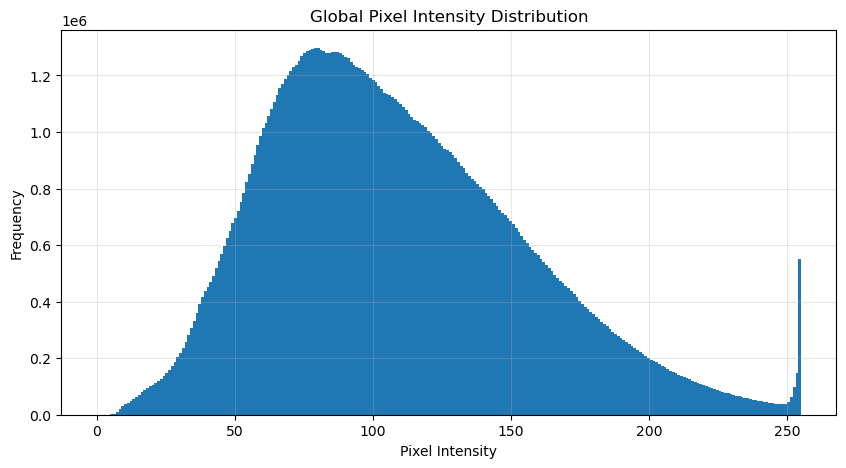

In [10]:
# ---------------------------------------------------------
# Collect Pixel Intensities
# ---------------------------------------------------------

all_pixels = []

for image_path in sorted(DATASET_ROOT.rglob("*.jpg")):

    image = np.array(Image.open(image_path))

    all_pixels.append(image.flatten())

all_pixels = np.concatenate(all_pixels)

# ---------------------------------------------------------
# Summary Statistics
# ---------------------------------------------------------

print("=" * 60)
print("PIXEL INTENSITY STATISTICS")
print("=" * 60)

print(f"Minimum Intensity : {all_pixels.min()}")
print(f"Maximum Intensity : {all_pixels.max()}")
print(f"Mean Intensity    : {all_pixels.mean():.2f}")
print(f"Median Intensity  : {np.median(all_pixels):.2f}")
print(f"Std Deviation     : {all_pixels.std():.2f}")

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    all_pixels,
    bins=256,
    range=(0,255)
)

plt.title("Global Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Observations

- **What do we observe?**  
  The pixel intensity distribution is unimodal with most pixel values concentrated between **50 and 150**. The distribution is positively skewed with a noticeable spike at the maximum intensity (**255**).

  Images are predominantly composed of mid-tone grayscale intensities rather than extremely dark or extremely bright pixels.

- **Why does it matter?**  
  Most images occupy the mid-gray intensity range with moderate brightness. The spike at **255** indicates the presence of saturated white pixels, likely caused by illumination or reflective regions. This should be considered when evaluating illumination consistency.

- **What decision does it lead to?**  
  The images already utilize a broad portion of the grayscale range. Before applying normalization or contrast enhancement, the consistency of image brightness should be evaluated across individual images.

## Research Question

> **RQ-006.3**

Are brightness levels consistent across the original grayscale images?

---

### Motivation

Variations in image brightness may arise from differences in illumination or image acquisition conditions. Understanding this variability helps determine whether brightness normalization or illumination correction is required before model training.

---

### Method

The average pixel intensity of each image is computed and analyzed to evaluate the distribution and variability of image brightness across the dataset.

---

IMAGE BRIGHTNESS STATISTICS
Minimum : 49.00
Maximum : 221.86
Mean    : 110.20
Median  : 108.51
Std Dev : 33.69


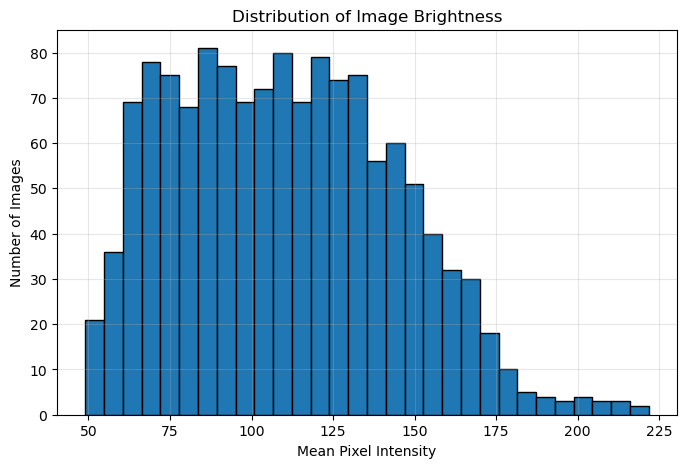

In [11]:
# ---------------------------------------------------------
# Mean Brightness of Each Image
# ---------------------------------------------------------

image_df["mean_brightness"] = image_df["path"].apply(
    lambda p: np.array(Image.open(p)).mean()
)

# ---------------------------------------------------------
# Summary Statistics
# ---------------------------------------------------------

brightness = image_df["mean_brightness"]

print("=" * 60)
print("IMAGE BRIGHTNESS STATISTICS")
print("=" * 60)

print(f"Minimum : {brightness.min():.2f}")
print(f"Maximum : {brightness.max():.2f}")
print(f"Mean    : {brightness.mean():.2f}")
print(f"Median  : {brightness.median():.2f}")
print(f"Std Dev : {brightness.std():.2f}")

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    brightness,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Brightness")

plt.grid(alpha=0.3)

plt.show()

### Observations

- **What do we observe?**  
  The average image brightness varies from **49.00** to **221.86**, indicating noticeable illumination differences across the dataset. Most images have mean brightness between **70 and 150**, while a small number of images are substantially brighter.

- **Why does it matter?**  
  Variations in illumination may influence feature extraction and model learning, particularly for subtle surface defects.

- **What decision does it lead to?**  
  The dataset exhibits moderate brightness variability. Before applying any illumination normalization techniques, we should first investigate whether image contrast is also consistent across the dataset.

## Research Question

> **RQ-006.4**

Is image contrast consistent across the dataset?

---

### Motivation

Image contrast determines how distinguishable defect regions are from the surrounding surface. Understanding contrast variability helps determine whether contrast enhancement techniques such as CLAHE or histogram equalization are necessary.

---

### Method

The RMS (Root Mean Square) contrast of each grayscale image is computed and analyzed across the dataset.


`Why RMS Contrast?`
There are many contrast measures:

Michelson Contrast
Weber Contrast
RMS Contrast
Local Contrast

For our project:

✅ RMS Contrast is the most appropriate because:

It is simple.
Works well for natural grayscale images.
Measures the overall intensity variation.
Is commonly used in image processing literature.

RMS CONTRAST STATISTICS
Minimum : 9.55
Maximum : 61.24
Mean    : 30.49
Median  : 29.91
Std Dev : 10.26


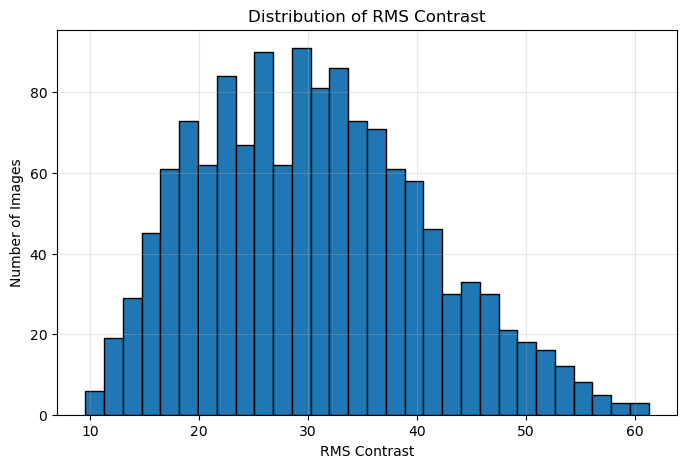

In [12]:
# ---------------------------------------------------------
# RMS Contrast
# ---------------------------------------------------------

def rms_contrast(image):
    image = image.astype(np.float32)
    return image.std()

image_df["rms_contrast"] = image_df["path"].apply(
    lambda p: rms_contrast(
        np.array(Image.open(p))
    )
)

contrast = image_df["rms_contrast"]

print("=" * 60)
print("RMS CONTRAST STATISTICS")
print("=" * 60)

print(f"Minimum : {contrast.min():.2f}")
print(f"Maximum : {contrast.max():.2f}")
print(f"Mean    : {contrast.mean():.2f}")
print(f"Median  : {contrast.median():.2f}")
print(f"Std Dev : {contrast.std():.2f}")

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    contrast,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of RMS Contrast")
plt.xlabel("RMS Contrast")
plt.ylabel("Number of Images")

plt.grid(alpha=0.3)

plt.show()

### Observations

- **What do we observe?**  
  The RMS contrast ranges from **9.55** to **61.24**, with most images concentrated between **20** and **40**. The distribution is unimodal with relatively moderate variability.

- **Why does it matter?**  
  Consistent image contrast indicates that defect visibility is relatively stable across the dataset, reducing the likelihood that contrast differences alone will adversely affect model learning.

- **What decision does it lead to?**  
  The dataset does not exhibit extreme contrast variability. Contrast enhancement techniques such as CLAHE should be treated as optional preprocessing steps and only adopted if experimental evaluation demonstrates a measurable improvement.

## Research Question

> **RQ-006.5**

Are there images with defects less visible that could negatively affect model training??

---

### Motivation

Surface defects such as cracks and blowholes contain fine structural details. Blur or poor focus may reduce their visibility and negatively affect segmentation performance.

---

### Method

Image sharpness is estimated using the **Variance of the Laplacian**, a widely used focus measure. Higher values indicate sharper images, while lower values suggest blur.

- In grayscale images, an edge represents a rapid change in intensity, such as a shift from dark to light within a small number of pixels. This transition is mathematically captured using gradients, which measure changes in pixel intensity. In the image above, the noticeable transition of pixel values from 0 to 240 indicates a significant intensity change. It’s evident that the pixels with a value of 100 correspond to the edge pixels.

## Laplacian Operator

The **Laplacian operator** is a second-order derivative operator that highlights regions of rapid intensity change, making it highly effective for isotropic (direction-independent) edge detection. Unlike directional filters like the Sobel operator, the Laplacian is **non-directional** and detects edges uniformly in all directions.

---

### Mathematical Formulation

In continuous space, for a 2D image function $f(x, y)$, the Laplacian $\nabla^2 f$ is defined as the sum of the second-order partial derivatives:

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

In discrete digital image processing, central differences are used to approximate these derivatives:

$$\frac{\partial^2 f}{\partial x^2} \approx f(x+1, y) + f(x-1, y) - 2f(x, y)$$

$$\frac{\partial^2 f}{\partial y^2} \approx f(x, y+1) + f(x, y-1) - 2f(x, y)$$

Combining both gives the discrete 2D Laplacian operator:

$$\nabla^2 f(x, y) \approx f(x+1, y) + f(x-1, y) + f(x, y+1) + f(x, y-1) - 4f(x, y)$$

---

### Discrete Convolution Kernels

In practice, this operator is applied to images using spatial convolution matrices (kernels):

#### 1. 4-Neighbor Kernel
Considers only orthogonal neighbors (horizontal and vertical):

$$K_4 = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

#### 2. 8-Neighbor Kernel
Includes diagonal neighbors for smoother, more isotropic edge response:

$$K_8 = \begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$

> **Note:** Inverted variations of these kernels (with positive central elements and negative outer elements, e.g., center $+4$ or $+8$) are also commonly used depending on the framework implementation.

In [13]:
import cv2
# ---------------------------------------------------------
# Variance of Laplacian
# ---------------------------------------------------------

defective_df = image_df[image_df["class"] != "MT_Free"]

def variance_of_laplacian(image):
    image = image.astype(np.uint8)
    return cv2.Laplacian(image, cv2.CV_64F).var()

defective_df["sharpness"] = defective_df["path"].apply(
    lambda p: variance_of_laplacian(
        np.array(Image.open(p))
    )
)

sharpness = defective_df["sharpness"]

# ---------------------------------------------------------
# Sort by Sharpness
# ---------------------------------------------------------

lowest_sharpness = (
    defective_df
    .sort_values("sharpness")
    .head(5)
)

highest_sharpness = (
    defective_df
    .sort_values("sharpness", ascending=False)
    .head(5)
)

display(lowest_sharpness[
    ["class", "sharpness", "path"]
])

display(highest_sharpness[
    ["class", "sharpness", "path"]
])





C:\Users\Pradhuman\AppData\Local\Temp\ipykernel_24104\282870751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defective_df["sharpness"] = defective_df["path"].apply(


,class,sharpness,path
12,MT_Blowhole,62.483452,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
31,MT_Blowhole,70.617993,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
262,MT_Fray,71.430172,..\data\raw\magnetic_tile\MT_Fray\Imgs\exp1_nu...
9,MT_Blowhole,74.748722,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
259,MT_Fray,87.184020,..\data\raw\magnetic_tile\MT_Fray\Imgs\exp1_nu...


,class,sharpness,path
111,MT_Blowhole,2299.503307,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
106,MT_Blowhole,2076.767271,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
97,MT_Blowhole,1904.976961,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
92,MT_Blowhole,1866.533302,..\data\raw\magnetic_tile\MT_Blowhole\Imgs\exp...
248,MT_Crack,1776.430738,..\data\raw\magnetic_tile\MT_Crack\Imgs\exp6_n...


- These are images which have lowest and highest sharpness in the entire dataset.
- If we manually look and check if they are not blurred or the defects are clearly visible, then we do not need preprocessing

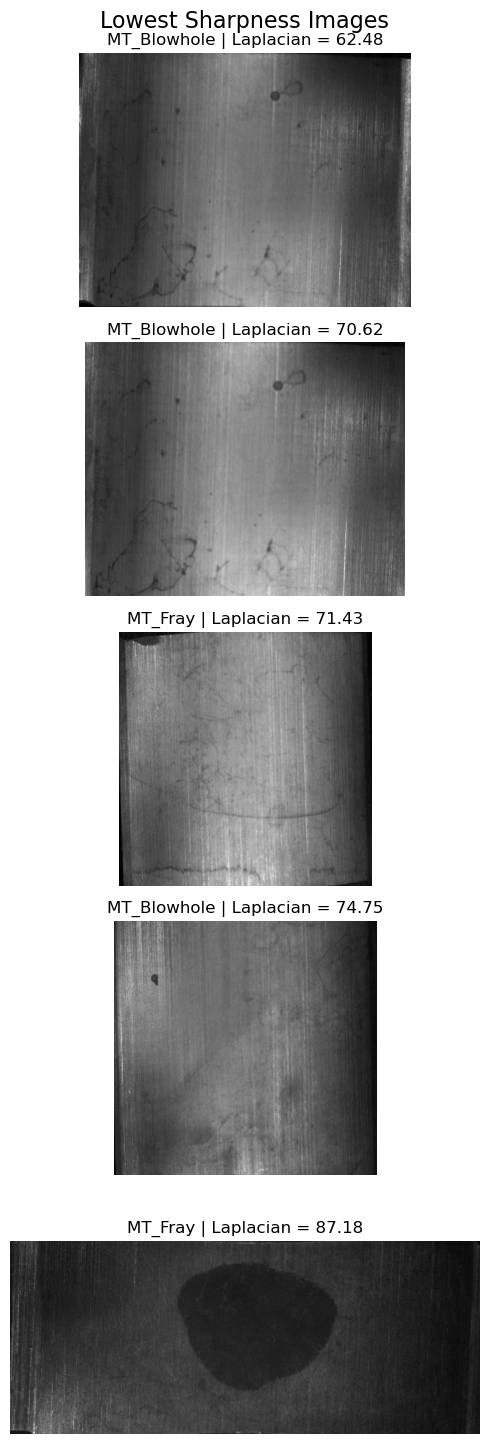

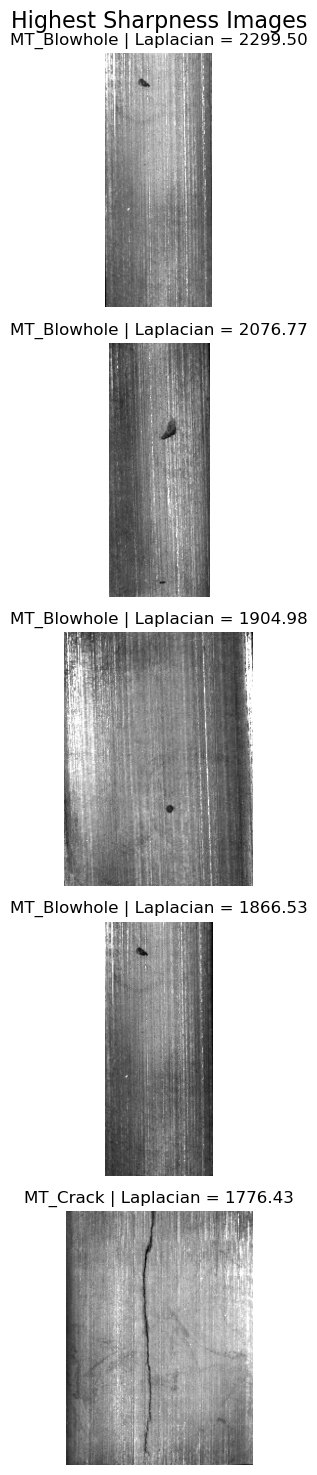

In [14]:
def visualize_samples(df, title):

    fig, axes = plt.subplots(
        len(df),
        1,
        figsize=(5, 3 * len(df))
    )

    fig.suptitle(title, fontsize=16)

    if len(df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df.iterrows()):

        image = Image.open(row["path"])

        ax.imshow(image, cmap="gray")

        ax.set_title(
            f"{row['class']} | Laplacian = {row['sharpness']:.2f}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.show()


visualize_samples(
    lowest_sharpness,
    "Lowest Sharpness Images"
)

visualize_samples(
    highest_sharpness,
    "Highest Sharpness Images"
)

### Reusable Functions For This Notebook

## Research Question

> **RQ-006.6**

Do the defect classes exhibit significantly different image brightness characteristics?

---

### Motivation

If image brightness differs substantially across defect classes, a deep learning model may exploit global illumination differences rather than learning defect-specific features. Understanding these differences helps determine whether brightness normalization is necessary before model training.

---

### Statistical Hypotheses

**Null Hypothesis (H₀)**

The mean image brightness is identical across all defect classes.

$$
\mu_{Free}=\mu_{Blowhole}=\mu_{Break}=\mu_{Crack}=\mu_{Fray}=\mu_{Uneven}
$$

**Alternative Hypothesis (H₁)**

At least one defect class has a significantly different mean image brightness.

<Figure size 1000x600 with 0 Axes>

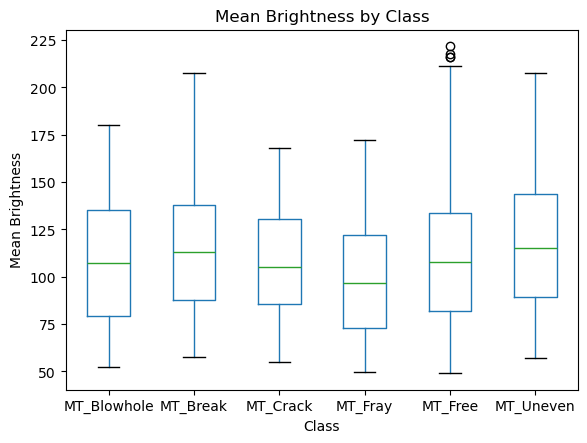

STATISTICAL COMPARISON REPORT

Feature Information
----------------------------------------------------------------------
Feature               : mean_brightness
Number of Groups      : 6
Total Samples         : 1344
Significance Level    : α = 0.05

STEP 1 : NORMALITY ASSUMPTION

Test
----------------------------------------------------------------------
Shapiro-Wilk Test

Purpose
----------------------------------------------------------------------
Checks whether each group's observations
are approximately normally distributed.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α


,Class,Statistic,p-value,Normal
0,MT_Blowhole,0.970511,1.219121e-02,False
1,MT_Break,0.977138,1.356000e-01,True
2,MT_Crack,0.964451,9.215992e-02,True
3,MT_Fray,0.955441,2.053088e-01,True
4,MT_Free,0.976300,2.459277e-11,False
5,MT_Uneven,0.971927,2.725678e-02,False



Summary
----------------------------------------------------------------------
Groups Passed         : 3
Groups Failed         : 3

Failed Classes
• MT_Blowhole
• MT_Free
• MT_Uneven

Conclusion
----------------------------------------------------------------------
✗ Normality assumption NOT satisfied.

STEP 2 : HOMOGENEITY OF VARIANCE

Test
----------------------------------------------------------------------
Levene's Test

Purpose
----------------------------------------------------------------------
Checks whether all groups have equal variance.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α

Statistic            : 0.4955
P-value              : 0.779826

Conclusion
----------------------------------------------------------------------
✓ Equal variance assumption satisfied.

STEP 3 : TEST SELECTION

Preferred Test
----------------------------------------------------------------------
One-Way ANOVA

Status
-------------

In [15]:
from src.utils.statistical_analysis import (
    compare_groups,
    print_statistical_report,
)

brightness = compare_groups(
    image_df,
    feature="mean_brightness",
)

print_statistical_report(brightness)

### Observations

- **What do we observe?**  
  The Kruskal–Wallis test found no statistically significant difference in image brightness across the six defect classes.

- **Why does it matter?**  
  This indicates that the overall brightness of an image is not strongly associated with its defect category.

- **What decision does it lead to?**  
  Brightness normalization is unlikely to improve class separability and should not be introduced solely for distinguishing defect classes.

## Research Question

> **RQ-006.7**

Do the defect classes exhibit significantly different image contrast characteristics?

---

### Statistical Hypotheses

**Null Hypothesis (H₀)**

The image contrast distributions are identical across all defect classes.

$$
\mu_{Free}=\mu_{Blowhole}=\mu_{Break}=\mu_{Crack}=\mu_{Fray}=\mu_{Uneven}
$$

**Alternative Hypothesis (H₁)**

At least one defect class exhibits a different contrast distribution.


<Figure size 1000x600 with 0 Axes>

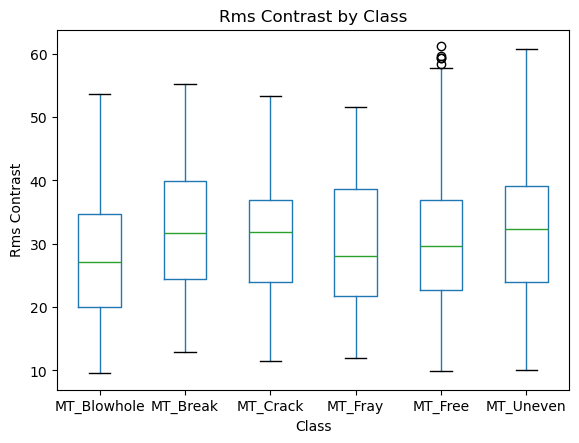

STATISTICAL COMPARISON REPORT

Feature Information
----------------------------------------------------------------------
Feature               : rms_contrast
Number of Groups      : 6
Total Samples         : 1344
Significance Level    : α = 0.05

STEP 1 : NORMALITY ASSUMPTION

Test
----------------------------------------------------------------------
Shapiro-Wilk Test

Purpose
----------------------------------------------------------------------
Checks whether each group's observations
are approximately normally distributed.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α


,Class,Statistic,p-value,Normal
0,MT_Blowhole,0.970425,1.198649e-02,False
1,MT_Break,0.980621,2.305981e-01,True
2,MT_Crack,0.979407,4.386987e-01,True
3,MT_Fray,0.955031,1.999413e-01,True
4,MT_Free,0.981170,9.577015e-10,False
5,MT_Uneven,0.990613,6.954923e-01,True



Summary
----------------------------------------------------------------------
Groups Passed         : 4
Groups Failed         : 2

Failed Classes
• MT_Blowhole
• MT_Free

Conclusion
----------------------------------------------------------------------
✗ Normality assumption NOT satisfied.

STEP 2 : HOMOGENEITY OF VARIANCE

Test
----------------------------------------------------------------------
Levene's Test

Purpose
----------------------------------------------------------------------
Checks whether all groups have equal variance.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α

Statistic            : 0.1913
P-value              : 0.965939

Conclusion
----------------------------------------------------------------------
✓ Equal variance assumption satisfied.

STEP 3 : TEST SELECTION

Preferred Test
----------------------------------------------------------------------
One-Way ANOVA

Status
-------------------------

In [21]:
contrast_results = compare_groups(
    image_df,
    feature="rms_contrast"
)

print_statistical_report(contrast_results)

### Observations

- **What do we observe?**  
  No statistically significant difference was found in image contrast across the six defect classes.

- **Why does it matter?**  
  This suggests that the overall contrast of an image is largely independent of the defect category.

- **What decision does it lead to?**  
  Global image contrast is unlikely to be a useful discriminative feature for separating defect classes.

## Research Question (RQ-006.8)

### Research Question

**Do the defect classes exhibit significantly different image sharpness characteristics?**

---

### Why are we investigating this?

Image sharpness reflects the amount of high-frequency information present in an image and is commonly used as an indicator of image focus and edge clarity. If certain defect classes consistently exhibit different sharpness levels, a CNN may partially rely on this global characteristic instead of learning the actual defect morphology.

---

### Null Hypothesis (H₀)

The image sharpness distributions are identical across all defect classes.

### Alternative Hypothesis (H₁)

At least one defect class exhibits a significantly different image sharpness distribution.

<Figure size 1000x600 with 0 Axes>

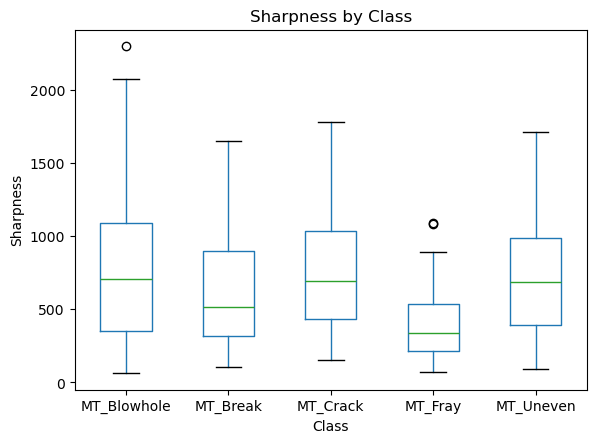

STATISTICAL COMPARISON REPORT

Feature Information
----------------------------------------------------------------------
Feature               : sharpness
Number of Groups      : 5
Total Samples         : 392
Significance Level    : α = 0.05

STEP 1 : NORMALITY ASSUMPTION

Test
----------------------------------------------------------------------
Shapiro-Wilk Test

Purpose
----------------------------------------------------------------------
Checks whether each group's observations
are approximately normally distributed.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α


,Class,Statistic,p-value,Normal
0,MT_Blowhole,0.945462,0.000144,False
1,MT_Break,0.913581,0.000029,False
2,MT_Crack,0.963050,0.079175,True
3,MT_Fray,0.893214,0.004179,False
4,MT_Uneven,0.953429,0.001154,False



Summary
----------------------------------------------------------------------
Groups Passed         : 1
Groups Failed         : 4

Failed Classes
• MT_Blowhole
• MT_Break
• MT_Fray
• MT_Uneven

Conclusion
----------------------------------------------------------------------
✗ Normality assumption NOT satisfied.

STEP 2 : HOMOGENEITY OF VARIANCE

Test
----------------------------------------------------------------------
Levene's Test

Purpose
----------------------------------------------------------------------
Checks whether all groups have equal variance.

Decision Rule
----------------------------------------------------------------------
Reject H₀ if p-value < α

Statistic            : 3.9165
P-value              : 0.003945

Conclusion
----------------------------------------------------------------------
✗ Equal variance assumption NOT satisfied.

STEP 3 : TEST SELECTION

Preferred Test
----------------------------------------------------------------------
One-Way ANOVA

Statu

In [23]:
sharpness_results = compare_groups(
    data=defective_df,
    feature="sharpness",
)

print_statistical_report(sharpness_results)

### Results

| Test | Statistic | P-value |
|------|----------:|---------:|
| Kruskal–Wallis H Test | **22.583** | **0.000153** |

Since **p < 0.05**, the null hypothesis is **rejected**.

### Observations

- **What do we observe?**  
  A statistically significant difference in image sharpness was found among the defective classes.

- **Why does it matter?**  
  This indicates that certain defect types consistently exhibit different levels of edge clarity and fine structural detail.

- **What decision does it lead to?**  
  A post-hoc pairwise comparison is required to identify which defect classes differ significantly in sharpness.

## Research Question (RQ-006.8.1)

>**Which defective classes exhibit significantly different image sharpness characteristics?**

---

### Why are we investigating this?

The Kruskal–Wallis test confirmed that image sharpness differs significantly among the defective classes. However, it does not identify which specific class pairs are responsible for this difference. Therefore, a post-hoc pairwise comparison is required.

---

### What does Dunn's Test do?

Dunn's test performs pairwise comparisons between all defect classes to identify which pairs exhibit statistically significant differences while controlling for multiple comparisons.

---

### Null Hypothesis (H₀)

The two defect classes being compared have identical sharpness distributions.

### Alternative Hypothesis (H₁)

The two defect classes being compared have different sharpness distributions.

,MT_Blowhole,MT_Break,MT_Crack,MT_Fray,MT_Uneven
MT_Blowhole,1.000000,0.458393,1.000000,0.000370,1.000000
MT_Break,0.458393,1.000000,0.366404,0.034398,0.458393
MT_Crack,1.000000,0.366404,1.000000,0.000379,1.000000
MT_Fray,0.000370,0.034398,0.000379,1.000000,0.000379
MT_Uneven,1.000000,0.458393,1.000000,0.000379,1.000000


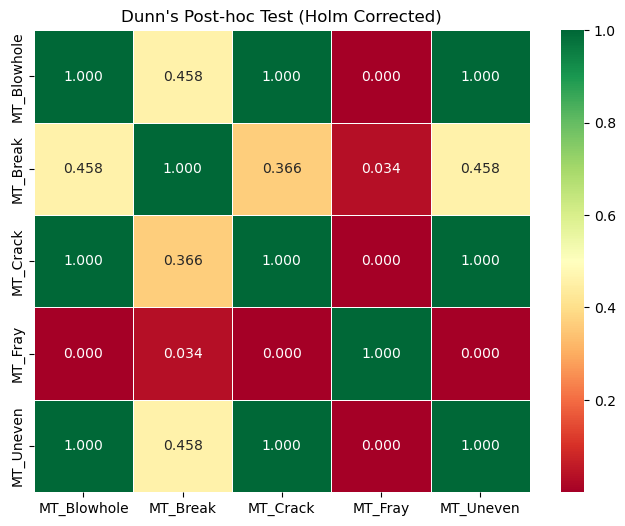

In [25]:
# %pip install scikit-posthocs
import scikit_posthocs as sp
dunn_results = sp.posthoc_dunn(
    defective_df,
    val_col="sharpness",
    group_col="class",
    p_adjust="holm"
)

display(dunn_results)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    dunn_results,
    annot=True,
    cmap="RdYlGn",
    fmt=".3f",
    linewidths=0.5,
)

plt.title("Dunn's Post-hoc Test (Holm Corrected)")
plt.show()

### Results

Dunn's post-hoc test with Holm correction was performed following the significant Kruskal–Wallis test to identify which defect classes differ in image sharpness.

---

### Observations

- **What do we observe?**  
  MT_Fray is the only defect class that exhibits statistically significant differences in sharpness compared with all other defective classes.

- **Why does it matter?**  
  The overall significance detected by the Kruskal–Wallis test is primarily driven by the MT_Fray class, while the remaining defect classes exhibit similar sharpness distributions.

- **What decision does it lead to?**  
  Image sharpness appears to be a distinguishing characteristic for MT_Fray but is unlikely to separate the other defect classes.

### Engineering Insight

The significant difference in image sharpness is primarily driven by the **MT_Fray** class. During the qualitative inspection, fray defects were observed to occupy substantially larger regions than the other defect types, producing stronger edges and more high-frequency image content. This naturally results in higher Variance of Laplacian values.

Therefore, the observed statistical difference is consistent with the visual characteristics of the dataset rather than being an artifact of the sharpness metric. While sharpness may help distinguish **MT_Fray** from the remaining defect classes, it is unlikely to separate **MT_Blowhole**, **MT_Break**, **MT_Crack**, and **MT_Uneven**, whose sharpness distributions are statistically similar.

# Notebook Conclusions

- The dataset contains images with varying resolutions and aspect ratios, making image resizing a necessary preprocessing step before training.
- Global pixel intensity analysis showed that the images have consistent grayscale characteristics and were acquired under relatively uniform illumination conditions.
- Statistical analysis revealed **no significant differences in image brightness or contrast** across the defect classes, indicating that these global image properties are unlikely to contribute to class discrimination.
- Image sharpness exhibited a **statistically significant difference** among the defective classes. Post-hoc analysis identified **MT_Fray** as the primary source of this difference.
- Visual inspection supported the statistical findings, as fray defects occupy substantially larger regions than the other defect types, naturally producing stronger edges and higher Variance of Laplacian values.
- Overall, the dataset appears to be consistently captured, suggesting that the segmentation model should primarily learn **localized defect morphology, texture, and spatial characteristics** rather than relying on global image quality attributes such as brightness or contrast.